<a href="https://colab.research.google.com/github/chaturvedulakashyap-source/Hyperexcitability-in-epilepsy/blob/main/Hyperexcitability_epilepsy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 55.6 MB/s eta 0:00:00


INFO       width adjusted from 5. ms to 5.1 ms [brian2.monitors.ratemonitor.adjusted_width]


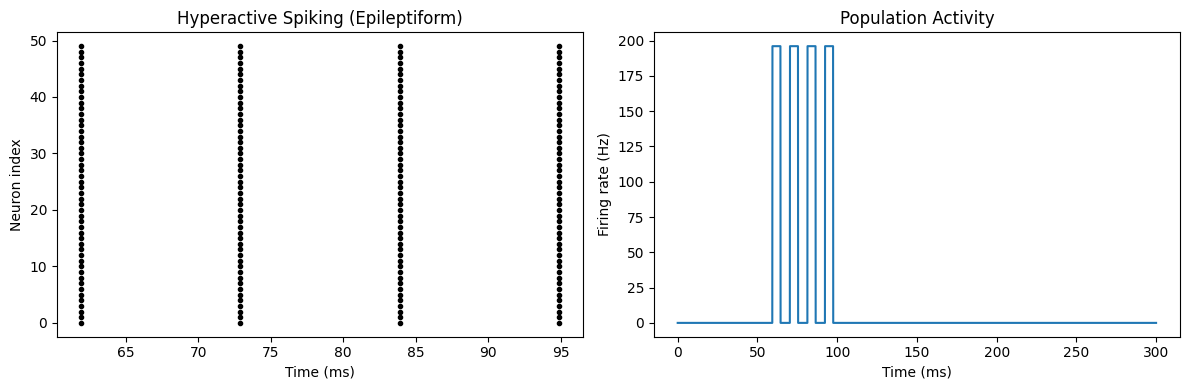

In [1]:
!pip install brian2 matplotlib

from brian2 import *
import matplotlib.pyplot as plt

start_scope()

# ---------------- PARAMETERS ----------------
N = 50
tau = 10*ms
w = 0.9   # high excitatory weight → hyperactivity

# ---------------- MODEL ----------------
eqs = '''
dv/dt = (-v + I) / tau : 1
I : 1
'''

# ---------------- NEURONS ----------------
G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
G.v = 'rand()'
G.I = 0

# ---------------- SYNAPSES ----------------
S = Synapses(G, G, on_pre='v_post += w')
S.connect(p=0.2)

# ---------------- MONITORS ----------------
spike_mon = SpikeMonitor(G)
rate_mon = PopulationRateMonitor(G)

# ---------------- STIMULUS ----------------
@network_operation(dt=1*ms)
def stimulus(t):
    if 50*ms < t < 100*ms:
        G.I = 1.5   # brief trigger
    else:
        G.I = 0

# ---------------- RUN ----------------
run(300*ms)

# ---------------- PLOTS ----------------
plt.figure(figsize=(12,4))

# Spike raster
plt.subplot(121)
plt.plot(spike_mon.t/ms, spike_mon.i, '.k')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Hyperactive Spiking (Epileptiform)')

# Population firing rate
plt.subplot(122)
plt.plot(rate_mon.t/ms, rate_mon.smooth_rate(window='flat', width=5*ms)/Hz)
plt.xlabel('Time (ms)')
plt.ylabel('Firing rate (Hz)')
plt.title('Population Activity')

plt.tight_layout()
plt.show()